<a href="https://colab.research.google.com/github/kiyara17777/IMDb-Movie-Review-Sentiment-Analysis-using-TF-IDF-and-Logistic-Regression/blob/main/sentiment__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews
['IMDB Dataset.csv']


In [2]:
df = pd.read_csv(
    os.path.join(path, "IMDB Dataset.csv")
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
!pip install kagglehub -q

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


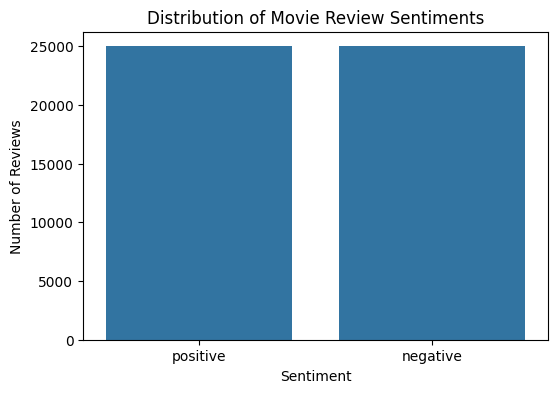

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="sentiment")

plt.title("Distribution of Movie Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
print("Number of duplicate reviews:", df["review"].duplicated().sum())

Number of duplicate reviews: 418


In [7]:
df = df.drop_duplicates(subset="review")

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (49582, 2)


In [8]:
def clean_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review"]].head())

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [10]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "label"]].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


In [11]:
X = df["clean_review"]
y = df["label"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    min_df=2,
    max_features=50000
)

In [14]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 50000)
Testing TF-IDF shape: (9917, 50000)


In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [16]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 89.48 %


In [18]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4940
    Positive       0.88      0.91      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.90      0.89      0.89      9917
weighted avg       0.90      0.89      0.89      9917



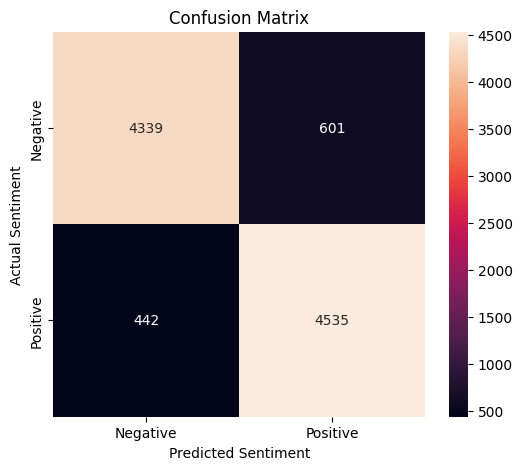

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [20]:
def predict_sentiment(review):

    # Clean the review
    cleaned_review = clean_text(review)

    # Convert to TF-IDF
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict
    prediction = model.predict(review_tfidf)[0]

    # Get probabilities
    probabilities = model.predict_proba(review_tfidf)[0]

    if prediction == 1:
        sentiment = "POSITIVE"
        confidence = probabilities[1]
    else:
        sentiment = "NEGATIVE"
        confidence = probabilities[0]

    print("Review:")
    print(review)

    print("\nPredicted Sentiment:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")

In [21]:
predict_sentiment(
    "This movie was absolutely amazing. The acting was brilliant and the story was very interesting."
)

Review:
This movie was absolutely amazing. The acting was brilliant and the story was very interesting.

Predicted Sentiment: POSITIVE
Confidence: 97.0 %


In [22]:
predict_sentiment(
    "This movie was extremely boring. The story was terrible and the acting was disappointing."
)

Review:
This movie was extremely boring. The story was terrible and the acting was disappointing.

Predicted Sentiment: NEGATIVE
Confidence: 99.98 %


In [23]:
feature_names = np.array(tfidf.get_feature_names_out())

coefficients = model.coef_[0]

top_positive = feature_names[np.argsort(coefficients)[-20:]]
top_negative = feature_names[np.argsort(coefficients)[:20]]

print("Top words associated with POSITIVE sentiment:")
print(top_positive)

print("\nTop words associated with NEGATIVE sentiment:")
print(top_negative)

Top words associated with POSITIVE sentiment:
['gem' 'definitely' 'fantastic' 'highly' 'enjoyable' 'hilarious' 'superb'
 'fun' 'today' 'love' 'enjoyed' 'brilliant' 'favorite' 'loved' 'wonderful'
 'amazing' 'perfect' 'best' 'excellent' 'great']

Top words associated with NEGATIVE sentiment:
['worst' 'awful' 'bad' 'waste' 'boring' 'poor' 'terrible' 'worse'
 'horrible' 'dull' 'poorly' 'fails' 'disappointment' 'annoying' 'supposed'
 'instead' 'save' 'lame' 'disappointing' 'minutes']


In [24]:
print("========== SENTIMENT ANALYSIS MODEL ==========")

print("Dataset size:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Feature Extraction: TF-IDF")
print("Machine Learning Algorithm: Logistic Regression")

print("Accuracy:", round(accuracy * 100, 2), "%")

========== SENTIMENT ANALYSIS MODEL ==========
Dataset size: 49582
Training samples: 39665
Testing samples: 9917
Feature Extraction: TF-IDF
Machine Learning Algorithm: Logistic Regression
Accuracy: 89.48 %
